**Program No. 16.  >> Case Study on Visualization**


**Objective:** To study real-life applications of visualization.


**Tasks:**
- Analyze a small case where visualization improves understanding

**Outcome:** Students will appreciate visualization in real-world decision-making.

**Case Study Version Using Your Rainfall Dataset**

We will create:

- 1️⃣ **Horizontal Bar Chart** → Rainfall by State (with national average target line)
- 2️⃣ **Bubble Chart** → Annual Rainfall vs Seasonal Rainfall (Bubble = Monthly Average)

This will look exactly like your vaccination example — but academic and realistic.

**Step 1:** Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")

**Step 2:** Load Dataset

In [5]:
df = pd.read_csv("district wise rainfall normal.csv")

df.columns = df.columns.str.strip().str.upper()

state_rainfall = df.groupby("STATE_UT_NAME")["ANNUAL"].mean().reset_index()

# Select Top 8 States
state_rainfall = state_rainfall.sort_values("ANNUAL", ascending=False).head(8)

**Step 3:** Aggregate State-wise Rainfall

In [6]:
state_rainfall = df.groupby("STATE_UT_NAME").agg({
    "ANNUAL": "mean",
    "JAN": "mean",
    "FEB": "mean",
    "MAR": "mean"
}).reset_index()

# Select top 5 states for clear visualization
state_rainfall = state_rainfall.sort_values("ANNUAL", ascending=False).head(5)

print(state_rainfall)

                  STATE_UT_NAME       ANNUAL        JAN        FEB         MAR
22                    MEGHALAYA  3682.842857  14.900000  21.685714   74.757143
10                          GOA  3278.500000   0.550000   0.050000    0.550000
17                       KERALA  2937.392857   9.542857  16.200000   31.071429
2             ARUNACHAL PRADESH  2927.375000  53.687500  93.293750  165.018750
0   ANDAMAN And NICOBAR ISLANDS  2911.400000  61.233333  33.266667   30.800000


**Step 4:** Now Perform Clean Visualization

**Visualization 1:** Attendance vs Percentage

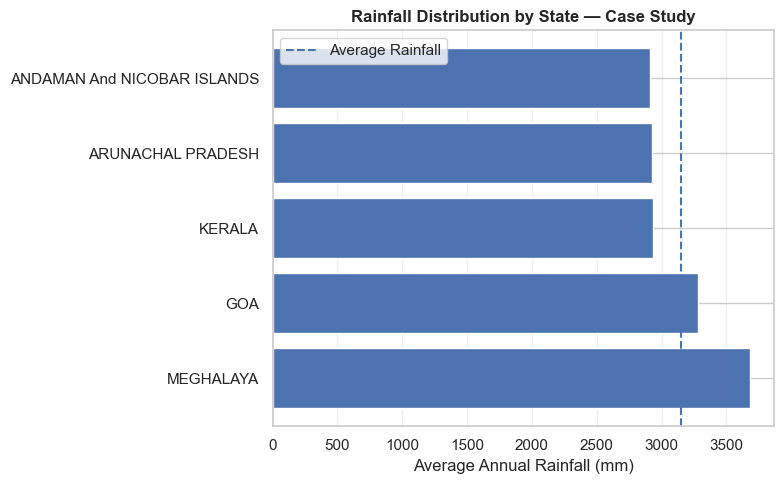

In [7]:
plt.figure(figsize=(8,5))

plt.barh(state_rainfall["STATE_UT_NAME"],
         state_rainfall["ANNUAL"])

national_avg = state_rainfall["ANNUAL"].mean()

plt.axvline(national_avg, linestyle="--", label="Average Rainfall")

plt.xlabel("Average Annual Rainfall (mm)")
plt.title("Rainfall Distribution by State — Case Study",
          fontweight="bold")

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\PRATI\AppData\Local\Temp\ipykernel_23716\721263049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


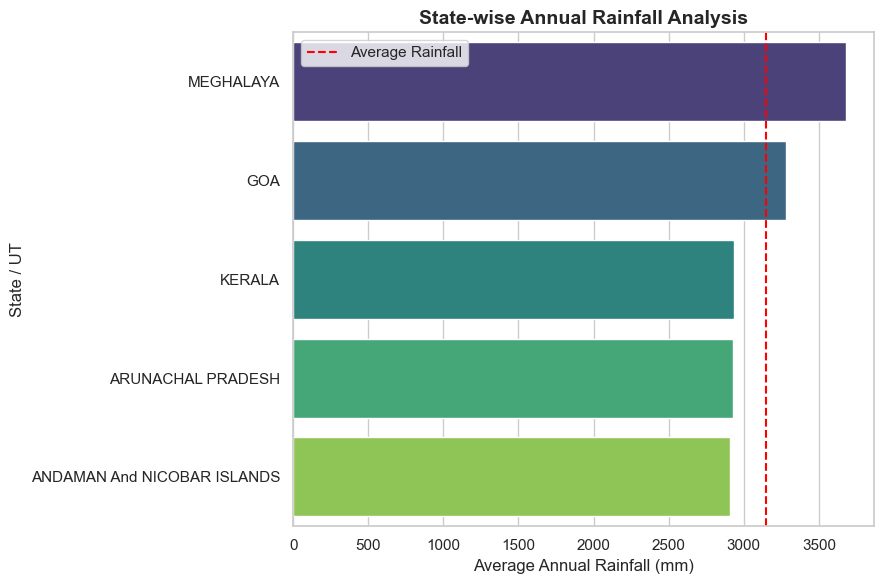

In [8]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=state_rainfall,
    x="ANNUAL",
    y="STATE_UT_NAME",
    palette="viridis"
)

plt.axvline(state_rainfall["ANNUAL"].mean(),
            linestyle="--",
            color="red",
            label="Average Rainfall")

plt.title("State-wise Annual Rainfall Analysis",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Average Annual Rainfall (mm)")
plt.ylabel("State / UT")

plt.legend()
plt.tight_layout()
plt.show()

**Visualization 2:** Seasonal vs Annual Rainfall

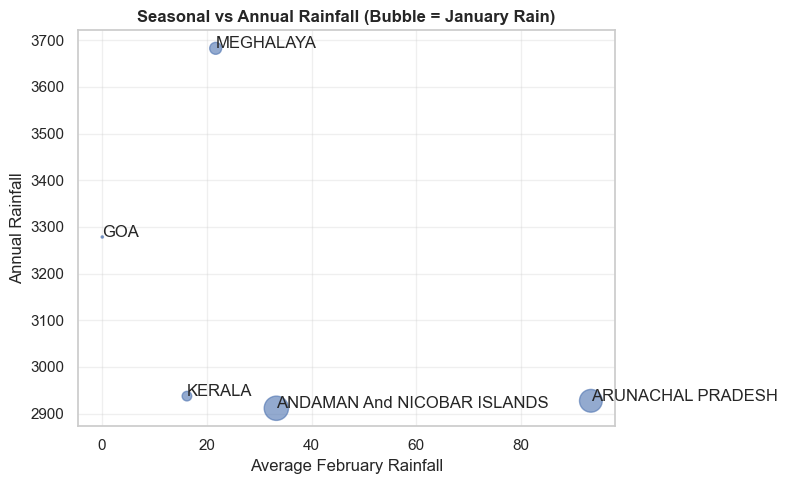

In [9]:
plt.figure(figsize=(8,5))

bubble_size = state_rainfall["JAN"] * 5

scatter = plt.scatter(
    state_rainfall["FEB"],
    state_rainfall["ANNUAL"],
    s=bubble_size,
    alpha=0.6
)

for i, txt in enumerate(state_rainfall["STATE_UT_NAME"]):
    plt.annotate(txt,
                 (state_rainfall["FEB"].iloc[i],
                  state_rainfall["ANNUAL"].iloc[i]))

plt.xlabel("Average February Rainfall")
plt.ylabel("Annual Rainfall")

plt.title("Seasonal vs Annual Rainfall (Bubble = January Rain)",
          fontweight="bold")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
dept_avg = df.groupby("department")["percentage"].mean().sort_values()

plt.figure(figsize=(9,5))

dept_avg.plot(kind="bar")

plt.title("Department-wise Average Percentage",
          fontweight="bold")

plt.xlabel("Department")
plt.ylabel("Average Percentage")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'department'

**From the first visualization:**
- States above the national average line receive higher rainfall.
- Water resource allocation can prioritize low-rainfall states.

**From the bubble chart:**
- Larger bubbles indicate high January rainfall contribution.
- States with strong seasonal dependency can be identified.
- Decision-makers can predict drought-prone regions.